In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

In [3]:
# print(os.getenv("GOOGLE_API_KEY"))

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

model=ChatGoogleGenerativeAI(model="gemini-flash-latest", google_api_key=os.getenv("GOOGLE_API_KEY"))
output=model.invoke("hi")
output.content


[{'type': 'text',
  'text': 'Hello! How can I help you today?',
  'extras': {'signature': 'EqACCp0CAQw51se3wsOrntUVbLl4fRbQMTIlOsHj9Rb5es5gYiThTT63spWOV7ce6Zlk5KsHlTIJ2NKyoRWyyuIytuBPbiPkKSkK04Mi8AITDTprdSH5mBabCh+PGZmzlqKquPg00EpIBKPTlxJXm95C4bc1KI5yEuGHdtFM3fFnSxVq7KtPpKx1GJsaDbmW8jkKJAnKLIivj2rDH3FPInvD+Cy1TBcNGvdchEw/pZfX/GzNTNUHdIu3hZ6qq0VJhh1IZFqvM5T72bcfhi+oKYzGd9fQ7hQt0ErmT3Mc//IF0LKQ67r+eWU3DSVpjNDxy+1HFwicnEMb31xr30x2ZtpR7woSP6CBnSWFJnk/f4IPn3Xtbj3d0u7OssvXJ4u3XBf5'}}]

#### Configure the Embedding Model

In [5]:
from langchain_huggingface import HuggingFaceEmbeddings
embeddings=HuggingFaceEmbeddings(model_name="BAAI/bge-small-en")
len(embeddings.embed_query("Hello, world!"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


384

#### Embedding & Storing the data in the Vector DB

In [6]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [7]:

loader=DirectoryLoader("../data2",glob="*.txt",loader_cls=TextLoader)

# DirectoryLoader("../data2",glob="*.txt",loader_cls=TextLoader)

In [8]:
docs=loader.load()

In [9]:
docs

[Document(metadata={'source': '../data2/usa.txt'}, page_content="🇺🇸 Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP – Size, Composition, and Global Share\nAs of 2024, the United States’ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (which rank

In [10]:
docs[0].page_content

"🇺🇸 Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP – Size, Composition, and Global Share\nAs of 2024, the United States’ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (which ranks 2nd). The U.S. GDP per capita is also among the highest, hover

In [11]:
text_splitter=RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=50)

In [12]:
new_docs=text_splitter.split_documents(docs)
new_docs


[Document(metadata={'source': '../data2/usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='innovation, global trade, and finan

In [13]:
doc_string=[doc.page_content for doc in new_docs]

In [14]:
doc_string

['🇺🇸 Overview of the U.S. Economy',
 'The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,',
 'It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a',
 'a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.',
 'innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.',
 'U.S. GDP – Size, Composition, and Global Share',
 'As of 2024, the United States’ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 

In [15]:
len(doc_string)

55

In [16]:
db=Chroma.from_documents(documents=new_docs, embedding=embeddings)

In [17]:
retriever=db.as_retriever(search_kwargs={"k": 3})

In [18]:
retriever.invoke("Industrial growth of USA?")

[Document(metadata={'source': '../data2/usa.txt'}, page_content='Looking forward, the U.S. economy is expected to grow at a moderate pace, powered by innovation in AI, green energy, robotics, biotech, and quantum computing. The Biden administration’s Inflation'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'),
 Document(metadata={'source': '../data2/usa.txt'}, page_content='The U.S. economy remains the engine of global growth, backed by unmatched innovation, financial dominance, and a strong institutional framework. Its $28 trillion GDP and influence over global')]

##### WORKFLOW CREATION

In [ ]:
from pydantic import BaseModel, Field
from typing import Annotated, Sequence, TypedDict
import operator
from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

In [20]:
## Creation of Pydantic Class

class TopicSelectionParser(BaseModel):
    topic: str = Field(description="The topic of the user's query")
    reasoning: str = Field(description="The reasoning for the topic selection")

In [21]:
from langchain_core.output_parsers import PydanticOutputParser

In [22]:
parser=PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [23]:
parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"topic": {"description": "The topic of the user\'s query", "title": "Topic", "type": "string"}, "reasoning": {"description": "The reasoning for the topic selection", "title": "Reasoning", "type": "string"}}, "required": ["topic", "reasoning"]}\n```'

In [24]:
'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"topic": {"description": "The topic of the user\'s query", "title": "Topic", "type": "string"}, "reasoning": {"description": "The reasoning for the topic selection", "title": "Reasoning", "type": "string"}}, "required": ["topic", "reasoning"]}\n```'

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"topic": {"description": "The topic of the user\'s query", "title": "Topic", "type": "string"}, "reasoning": {"description": "The reasoning for the topic selection", "title": "Reasoning", "type": "string"}}, "required": ["topic", "reasoning"]}\n```'

In [25]:
class Agentstate(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

# We have a agentstate and its of type dictionary. 'messages' is a key and its value is a list of BaseMessage.
# operator.add is a function that takes two lists and returns a new list that is the concatenation of the two lists. and we can add as many as messages we want to.
# Agent state is used to flow the input through different different nodes. 

In [26]:
def function_1(state: Agentstate):
    question=state['messages'][-1]
    print("Question", question)
    template='''Your task is to classify the given user query into one of the following
                categories: [USA, Not Related]. Only respond with the category name and nothing else.

                User Query: {question}
                {format_instructions}'''

    prompt=PromptTemplate(
        template=template,
        input_variables=['question'],
        partial_variables={'format_instructions': parser.get_format_instructions()}
    )
    chain= prompt | model | parser
    response=chain.invoke({"question": question})
    print("Response:", response)
    return {"messages": [response.topic]}


In [27]:
state={"messages":["what is the weather today?"]}

In [28]:
function_1(state)

Question what is the weather today?
Response: topic='Not Related' reasoning='The query asks for general weather information without specifying a location or context that links it specifically to the United States.'


{'messages': ['Not Related']}

In [29]:
state={"messages":["what is the GDP of USA?"]}

In [30]:
function_1(state)

Question what is the GDP of USA?
Response: topic='USA' reasoning='The user query explicitly asks for the Gross Domestic Product (GDP) of the United States (USA).'


{'messages': ['USA']}

In [31]:
state

{'messages': ['what is the GDP of USA?']}

In [32]:
def router(state: Agentstate):
    print("-> Router ->")
    last_message=state['messages'][-1]
    print("Last Message", last_message)

    if 'usa' in last_message.lower():
        return "RAG Call"
    else:
        return "LLM Call"

In [33]:
def format_docs(docs):
    return "\n".join([doc.page_content for doc in docs])

In [51]:
## RAG function
def function_2(state: Agentstate):
    print("-> RAG Call ->")

    question=state['messages'][0] 
    print("Question from function2", question)

    prompt=PromptTemplate(
        template="""
        You are a helpful assistant that can answer questions about the user's query.
        Use the following pieces of retrieved context to answer the question. If
        you don't know the answer just say that you don't know. Use 3 sentences maximum 
        to keep the answer concise. \nQuestion: {question} \nContext: {context} \nAnswer: """,
        
        input_variables=['context', 'question']
    )

    rag_chain=(
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | model
        | StrOutputParser()
    )

    # Pass raw question string so retriever gets text, not a dict.
    result=rag_chain.invoke(question)

    return {"messages": [result]}


In [52]:
def function_3(state: Agentstate):
    print("-> LLM Call ->")
    question=state['messages'][0]

    # Normal LLM call
    complete_query="Answer the following question with your knowledge of the real world. Following is the user's question: "+question
    
    response=model.invoke(complete_query)
    return {"messages": [response.content]}


In [53]:
# StateGraph creation, Stategraph means throughout the execution, state will be maintained.
from langgraph.graph import StateGraph, END

In [54]:
workflow=StateGraph(Agentstate)

In [55]:
workflow.add_node("Supervisor", function_1)

In [56]:
workflow.add_node("RAG", function_2)

In [57]:
workflow.add_node("LLM", function_3)

In [58]:
workflow.set_entry_point("Supervisor")

In [59]:
## CONDITIONAL EDGES
workflow.add_conditional_edges(
    "Supervisor",
    router,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
    }
)

In [60]:
workflow.add_edge("RAG", END)
workflow.add_edge("LLM", END)

In [61]:
app=workflow.compile()

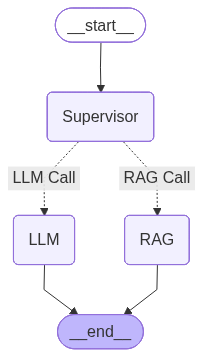

In [62]:
app

In [63]:
state={"messages": ["hi"]}

In [64]:
result=app.invoke(state)

Question hi
Response: topic='Not Related' reasoning="The query 'hi' is a generic greeting and does not contain any specific information or context related to the USA."
-> Router ->
Last Message Not Related
-> LLM Call ->


In [65]:
result

{'messages': ['hi',
  'Not Related',
  [{'type': 'text',
    'text': 'Hello! How can I help you today?',
    'extras': {'signature': 'EugBCuUBAQw51sddUASTk7LWqXlhbKGvQYA67RmYZG9N66EM2vNIZhUeanHTUpfiZwLVSiz02RM1j2BDDpW/8nAGlaun0y4Sd5J+Lq4QiZE2uEO3+vQxx/fVO8R/Oj2TpRM1xoa6gRwHVIUaD0s2vg4YFSfu+x3Ku/A0q3XySu8ObyN/iHrNXAxkG0Q/qs7ANaWCrWi9al62BWQPvoHKLFKs2NpG4BNTjqwXXHPJLzKN8RWH6udXZXMYNEGdKJeIsXNENz7CGyZJ1R1ezxGZGOOJIqB+jSaQT6FOfD64oFNq9mbCevn+Q0csVg=='}}]]}

In [66]:
state={"messages": ["Can you tell me about the GDP of USA?"]}

In [67]:
result=app.invoke(state)

Question Can you tell me about the GDP of USA?
Response: topic='USA' reasoning='The user query specifically asks for information about the Gross Domestic Product (GDP) of the United States, which directly relates to the USA category.'
-> Router ->
Last Message USA
-> RAG Call ->
Question from function2 Can you tell me about the GDP of USA?


In [68]:
result

{'messages': ['Can you tell me about the GDP of USA?',
  'USA',
  'As of 2024, the United States has a nominal GDP estimated at approximately $28 trillion USD, accounting for about 25% of the global economy. It currently ranks first in the world by nominal GDP, positioning it as the largest economy globally.']}

In [69]:
state={"messages": ["Can you tell me the industrial growth of world's most powerful economy?"]}

In [70]:
result=app.invoke(state)

Question Can you tell me the industrial growth of world's most powerful economy?
Response: topic='USA' reasoning="The term 'world's most powerful economy' is widely understood to refer to the United States, as it currently has the largest nominal GDP in the world."
-> Router ->
Last Message USA
-> RAG Call ->
Question from function2 Can you tell me the industrial growth of world's most powerful economy?


In [72]:
result['messages'][-1]

"The United States is identified as the world's most powerful economy with a $28 trillion nominal GDP and a capitalist mixed system. While the context describes the U.S. as an engine of global growth driven by innovation, it does not provide specific figures or details regarding its industrial growth. Therefore, I don't know the exact industrial growth rates based on the provided text."

In [73]:
state={"messages": ["Can you tell me the industrial growth of world's most poor economy?"]}

In [74]:
result=app.invoke(state)

Question Can you tell me the industrial growth of world's most poor economy?
Response: topic='Not Related' reasoning="The query asks about the world's poorest economy, which refers to developing nations (such as Burundi or South Sudan) rather than the USA, which is one of the world's largest and wealthiest economies."
-> Router ->
Last Message Not Related
-> LLM Call ->


In [75]:
result['messages'][-1]

[{'type': 'text',
  'text': 'To answer this question, we must first identify which country is currently considered the "world’s poorest economy." While rankings can shift slightly depending on whether you use **GDP per capita (Nominal)** or **GDP per capita (Purchasing Power Parity - PPP)**, **Burundi** is consistently ranked as the poorest nation in the world by the World Bank and IMF.\n\nHere is an overview of the industrial growth and economic structure of Burundi, along with a brief look at **South Sudan**, which often competes for this position.\n\n---\n\n### 1. Burundi (The World\'s Poorest Economy)\nBurundi is a landlocked, resource-poor country with an economy heavily dependent on subsistence agriculture.\n\n*   **Industrial Share of GDP:** The industrial sector is very small, typically accounting for only **15% to 18% of the total GDP**. For comparison, agriculture accounts for roughly 40%, and services for about 42%.\n*   **Nature of Industry:** Burundi’s "industry" is primar

## ASSIGNMENT:
1. Create supervisor.
2. Create Router:
    Router connected to - LLM, RAG, Web Crawler(Take info from internet, fetch info in real time from Internet -> use tavily)
3. Create one more node of validation of generated o/p
4. If validation fails, again go to supervisor -> supervisor decides what needs to be called next
5. Once validation passes, then only generate the output.